# Statistics Mini Project

Sales data analysis using hypothesis testing, distribution fitting, A/B testing, and correlation.

In [1]:
#importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

np.random.seed(42)

## 1. Sales Data

In [2]:
# A small example dataset
sales = np.array([
    48, 52, 51, 49, 55, 58, 53, 50, 47, 54,
    56, 52, 49, 51, 57, 60, 55, 53, 50, 59,
    61, 56, 54, 52, 58, 63, 57, 55, 51, 60,
    62, 59, 56, 54, 61, 64, 58, 57, 53, 62
])

print("Number of days:", len(sales))
print("Average sales:", round(sales.mean(), 2))
print("Standard deviation:", round(sales.std(ddof=1), 2))

Number of days: 40
Average sales: 55.3
Standard deviation: 4.42


## 2. Hypothesis Testing

The expected average sales is 55 per day.

- H0: mean sales = 55
- H1: mean sales ≠ 55

A one-sample t-test is used.

In [3]:
expected_sales = 55

t_stat, p_value = stats.ttest_1samp(sales, expected_sales)

print("t-statistic:", round(t_stat, 3))
print("p-value:", round(p_value, 4))

if p_value < 0.05:
    print("Result: Reject H0. The average looks significantly different from 55.")
else:
    print("Result: We do not have enough evidence to reject H0.")

t-statistic: 0.43
p-value: 0.6698
Result: We do not have enough evidence to reject H0.


### Sales Distribution

Histogram of the sales values.

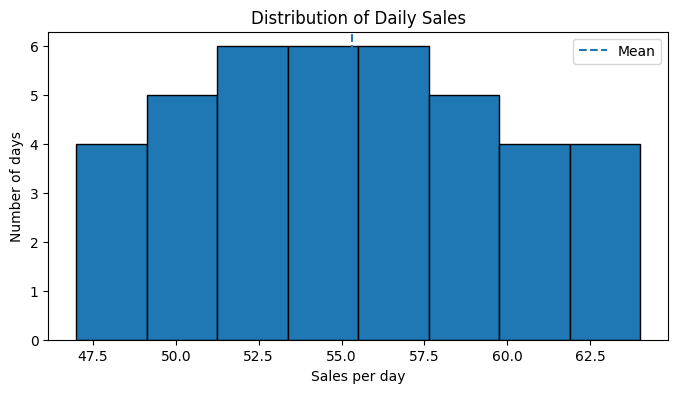

In [4]:
plt.figure(figsize=(8, 4))
plt.hist(sales, bins=8, edgecolor='black')
plt.axvline(sales.mean(), linestyle='--', label='Mean')
plt.xlabel('Sales per day')
plt.ylabel('Number of days')
plt.title('Distribution of Daily Sales')
plt.legend()
plt.show()

## 3. Distribution Fitting

Fit a normal distribution to the sales data using the sample mean and standard deviation.

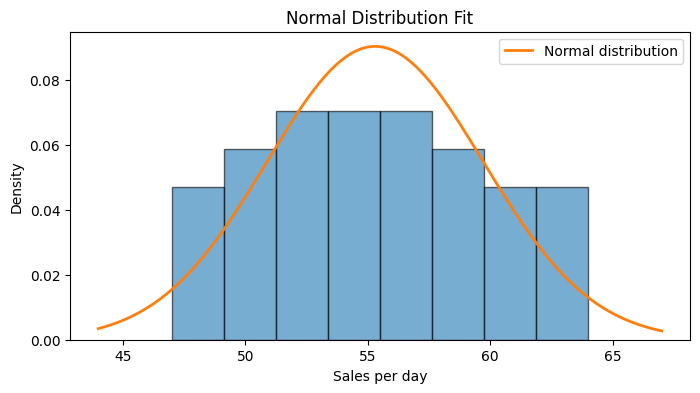

Fitted mean: 55.3
Fitted standard deviation: 4.42


In [5]:
mean = sales.mean()
std = sales.std(ddof=1)

x = np.linspace(sales.min() - 3, sales.max() + 3, 200)
normal_curve = stats.norm.pdf(x, mean, std)

plt.figure(figsize=(8, 4))
plt.hist(sales, bins=8, density=True, alpha=0.6, edgecolor='black')
plt.plot(x, normal_curve, linewidth=2, label='Normal distribution')
plt.xlabel('Sales per day')
plt.ylabel('Density')
plt.title('Normal Distribution Fit')
plt.legend()
plt.show()

print("Fitted mean:", round(mean, 2))
print("Fitted standard deviation:", round(std, 2))

In [6]:
# A simple goodness-of-fit check using the Kolmogorov-Smirnov test
ks_stat, ks_p = stats.kstest(sales, 'norm', args=(mean, std))

print("KS statistic:", round(ks_stat, 3))
print("KS p-value:", round(ks_p, 4))
print("This gives us a rough idea of how well a normal distribution fits the sample.")

KS statistic: 0.074
KS p-value: 0.9702
This gives us a rough idea of how well a normal distribution fits the sample.


## 4. A/B Test

Compare two versions of an online store button:

- A: old button
- B: new button

The conversion rates are compared using simulated data.

In [7]:
n = 1000

# Simulated conversion results: 0 = no conversion, 1 = conversion
group_a = np.random.binomial(1, 0.10, n)
group_b = np.random.binomial(1, 0.13, n)

conversion_a = group_a.mean()
conversion_b = group_b.mean()

print("A conversion rate:", round(conversion_a * 100, 2), "%")
print("B conversion rate:", round(conversion_b * 100, 2), "%")
print("Difference:", round((conversion_b - conversion_a) * 100, 2), "percentage points")

A conversion rate: 10.0 %
B conversion rate: 13.1 %
Difference: 3.1 percentage points


### A/B Test Result

A two-proportion z-test is used to check whether the conversion rates are significantly different.

In [8]:
success_a = group_a.sum()
success_b = group_b.sum()

p_pool = (success_a + success_b) / (2 * n)
se = np.sqrt(p_pool * (1 - p_pool) * (2 / n))

z = (conversion_b - conversion_a) / se
p_value_ab = 2 * (1 - stats.norm.cdf(abs(z)))

print("z-statistic:", round(z, 3))
print("p-value:", round(p_value_ab, 4))

if p_value_ab < 0.05:
    print("Result: The difference between A and B is statistically significant.")
else:
    print("Result: We do not have enough evidence that A and B are different.")

z-statistic: 2.169
p-value: 0.0301
Result: The difference between A and B is statistically significant.


## 5. Correlation Matrix

Correlation shows the relationship between numeric variables. A heatmap is used to visualize it.

In [9]:
df = pd.DataFrame({
    'Sales': sales,
    'Advertising': sales * 0.8 + np.random.normal(0, 8, len(sales)),
    'Website_Visits': sales * 12 + np.random.normal(0, 45, len(sales)),
    'Discount': np.random.uniform(5, 25, len(sales)),
    'Returns': np.random.poisson(3, len(sales))
})

df.head()

,Sales,Advertising,Website_Visits,Discount,Returns
0,48,31.376139,595.645191,20.865227,4
1,52,34.984957,664.677068,11.335234,2
2,51,38.988169,505.668040,22.143585,3
3,49,42.138924,542.562118,23.122865,1
4,55,51.308677,687.861942,10.538090,4


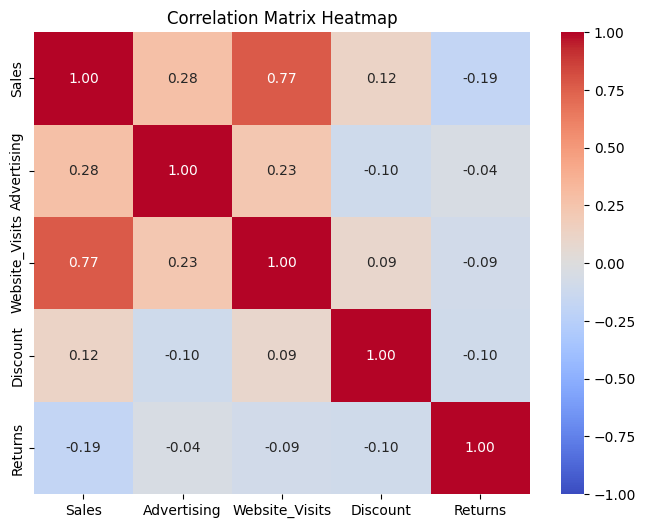

In [10]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')
plt.show()

## Conclusion

- Hypothesis testing checks claims about a population.
- Distribution fitting shows how well data follows a known distribution.
- A/B testing compares two versions using data.
- Correlation shows relationships between numeric variables.